In [1]:
from nrs import EType, NRS_Model, Element, NRS_Revision, NRS_Observer_E    # классы НРС
from nrs import NRS_Data as nd                                      # Табличные данные НРС
from nrs import q_out_simple, q_out_nozzle                          # модели расчета параметров
import matplotlib.pyplot as plt                                     # библиотеки для отрисовки получаемых данных

In [2]:
# Вычисляем проводимости гладкоствольных насадков для стволов Б (13мм) и А (19мм)
p_2 = NRS_Revision.calc_p(2, 40)
p_4 = NRS_Revision.calc_p(4, 40)
p_6 = NRS_Revision.calc_p(6, 40)
p_8 = NRS_Revision.calc_p(8, 40)
p_2, p_4, p_6, p_8

(0.31622776601683794,
 0.6324555320336759,
 0.9486832980505138,
 1.2649110640673518)

2 рукава 51, разветвление + 2 рабочих линии по 1 рукаву 51 + РСКУ-50А

Сборка модели

In [3]:
# Создаем модель НРС:
model = NRS_Model('Модель от одного насоса к двум стволам через одно разветвление')

# Создаем элементы модели:
pump = Element('Н1', 0, H_add=60)                                       # Насос
hoseM_1 = Element('МРЛ Н-Р1', 1, s=nd.ss["51"], n=2)                    # магистральная рукавная линия №1 - от насоса к разветвлению №1

splitter_1 = Element('Р1', 1, ro=3)                                           # разветвление №1
hoseW_11 = Element('РРЛ Р1-1', 1, s=nd.ss["51"], n=1)                   # рабочая рукавная линия от разветвления №1 к стволу №1
nozzle_11 = Element('Ствол 1', 2, p=p_2, q_out = q_out_nozzle)          # ствол №1
hoseW_12 = Element('РРЛ Р1-2', 1, s=nd.ss["51"], n=1)                   # рабочая рукавная линия от разветвления №1 к стволу №2
nozzle_12 = Element('Ствол 2', 2, p=p_8, q_out = q_out_nozzle)          # ствол №2

# Соединяем элементы модели вместе в НРС:
# Магистральная часть:
pump.append(hoseM_1).append(splitter_1)

splitter_1.append(hoseW_11).append(nozzle_11)   # Рукавная линия от разветвления №1 к стволу №1
splitter_1.append(hoseW_12).append(nozzle_12)   # Рукавная линия от разветвления №1 к стволу №2


# Добавляем обозревателей:
NRS_Observer_E(pump,      ['q', 'H_add'])               # Для насоса
NRS_Observer_E(nozzle_11, ['q', 'H_in'])                # Для ствола №1
NRS_Observer_E(nozzle_12, ['q', 'H_in'])                # Для ствола №2


# Строим модель и инициируем обозревателей:
# model.build(pump, interpretate=True)
model = model.build(pump, interpretate=True).observersInit()

# # Расчет НРС:
# model, r = model.calc(accuracy=0.05, fixStates=True)

# Печать результата расчета
def printResult():
    print(f'Производительность насоса: {round(pump.q, 2)} л/с')
    print(f'Напор на насосе:           {pump.H_add} м')
    print('Напоры на стволах')
    print('\t', f'Ствол 1: {round(nozzle_11.H_in, 2)} м,   Ствол 2: {round(nozzle_12.H_in, 2)} м')
    print('Производительности стволов')
    print('\t', f'Ствол 1: {round(nozzle_11.q, 2)} л/с,  Ствол 2: {round(nozzle_12.q, 2)} л/с')

In [4]:
print('Положение переключателя на стволе №2 = 8 л/с')
print('-'*80)
model, r = model.calc(accuracy=0.05, fixStates=True)

printResult()

Положение переключателя на стволе №2 = 8 л/с
--------------------------------------------------------------------------------
Производительность насоса: 9.07 л/с
Напор на насосе:           60 м
Напоры на стволах
	 Ствол 1: 37.9 м,   Ствол 2: 31.73 м
Производительности стволов
	 Ствол 1: 1.95 л/с,  Ствол 2: 7.13 л/с


In [5]:
print('Положение переключателя на стволе №2 = 2 л/с')
print('-'*80)

# Сброс состояния
model.drop_q()

# Расчет НРС с новыми параметрами:
# Напор на насосе
pump.set_H_add(60)
# Положение головки (p_2, p_4, p_6, p_8)
nozzle_12.p = p_2
model, r = model.calc(accuracy=0.05, fixStates=True)

printResult()

Положение переключателя на стволе №2 = 2 л/с
--------------------------------------------------------------------------------
Производительность насоса: 4.64 л/с
Напор на насосе:           60 м
Напоры на стволах
	 Ствол 1: 53.8 м,   Ствол 2: 53.8 м
Производительности стволов
	 Ствол 1: 2.32 л/с,  Ствол 2: 2.32 л/с


In [6]:
print('Положение переключателя на стволе №2 = 8 л/с')
print('-'*80)

# Сброс состояния
model.drop_q()

# Расчет НРС с новыми параметрами:
# Напор на насосе
pump.set_H_add(60)
# Положение головки (p_2, p_4, p_6, p_8)
nozzle_12.p = p_8
model, r = model.calc(accuracy=0.05, fixStates=True)

printResult()

Положение переключателя на стволе №2 = 8 л/с
--------------------------------------------------------------------------------
Производительность насоса: 9.11 л/с
Напор на насосе:           60 м
Напоры на стволах
	 Ствол 1: 38.13 м,   Ствол 2: 32.03 м
Производительности стволов
	 Ствол 1: 1.95 л/с,  Ствол 2: 7.16 л/с


In [7]:
print('Положение переключателя на стволе №2 = 0 л/с. Ствол перекрыт')
print('-'*80)

# Сброс состояния
model.drop_q()

# Расчет НРС с новыми параметрами:
# Напор на насосе
pump.set_H_add(60)
# Положение головки (p_2, p_4, p_6, p_8)
nozzle_12.p = 0
model, r = model.calc(accuracy=0.05, fixStates=True)

printResult()

Положение переключателя на стволе №2 = 0 л/с. Ствол перекрыт
--------------------------------------------------------------------------------
Производительность насоса: 2.4 л/с
Напор на насосе:           60 м
Напоры на стволах
	 Ствол 1: 57.66 м,   Ствол 2: 58.44 м
Производительности стволов
	 Ствол 1: 2.4 л/с,  Ствол 2: 0.0 л/с


# Анализ экспериментальных данных

In [8]:
# Сопротивление одного рукава 51 мм, эмпирическое:
ss51 = 0.075

# Создаем модель НРС:
model = NRS_Model('Модель от одного насоса к двум стволам через одно разветвление')

# Создаем элементы модели:
pump = Element('Н1', 0, H_add=10)                                       # Насос
hoseM_1 = Element('МРЛ Н-Р1', 1, s=ss51, n=3)                    # магистральная рукавная линия №1 - от насоса к разветвлению №1

splitter_1 = Element('Р1', 1, ro = 3)                                           # разветвление №1
hoseW_11 = Element('РРЛ Р1-1', 1, s = ss51, n=1)                   # рабочая рукавная линия от разветвления №1 к стволу №1
nozzle_11 = Element('Ствол 1', 2, p = p_2, q_out = q_out_nozzle)          # ствол №1 (положение 2 л/с)
hoseW_12 = Element('РРЛ Р1-2', 1, s = ss51, n=1)                   # рабочая рукавная линия от разветвления №1 к стволу №2
nozzle_12 = Element('Ствол 2', 2, p = p_8, q_out = q_out_nozzle)          # ствол №2 (положение 8 л/с)

# Соединяем элементы модели вместе в НРС:
# Магистральная часть:
pump.append(hoseM_1).append(splitter_1)

splitter_1.append(hoseW_11).append(nozzle_11)   # Рукавная линия от разветвления №1 к стволу №1
splitter_1.append(hoseW_12).append(nozzle_12)   # Рукавная линия от разветвления №1 к стволу №2


# Строим модель:
model = model.build(pump, interpretate=True)

In [9]:
NRS_Revision.print_model_elements(model)

Модель от одного насоса к двум стволам через одно разветвление
all:
  Н1
  МРЛ Н-Р1
  Р1
  РРЛ Р1-1
  Ствол 1
  РРЛ Р1-2
  Ствол 2
in:
  Н1
out:
  Ствол 1
  Ствол 2


### Эксперимент 1

- Ствол 1 - положение 2 л/с
- Ствол 2 - положение 8 л/с

In [10]:
# Насос
h_pump = []
q_pump = []
# Ствол 1
h_n1   = []
q_n1   = []
# Ствол 2
h_n2   = []
q_n2   = []

# Моделирование:
for h in range (10, 100):
    
    # Шаг моделирования
    model.drop_q()
    # Напор на насосе
    pump.set_H_add(h)
    model, r = model.calc(accuracy=0.05)

    # Запоминаем результат
    h_pump.append(h)
    q_pump.append(pump.q)
    h_n1.append(nozzle_11.H_in)
    q_n1.append(nozzle_11.q)
    h_n2.append(nozzle_12.H_in)
    q_n2.append(nozzle_12.q)


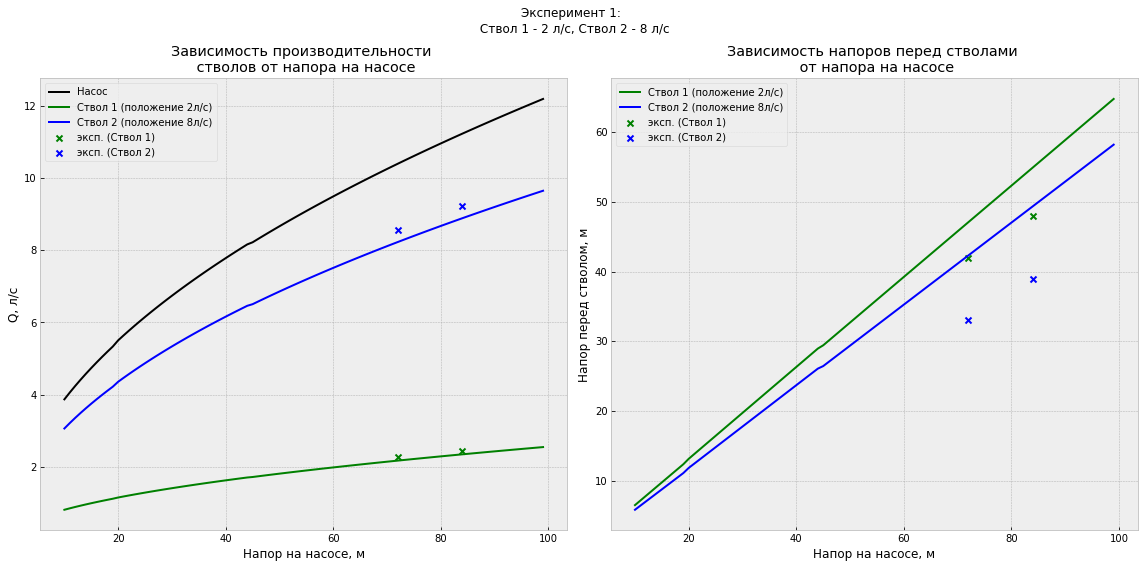

In [11]:
plt.style.use('bmh')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

ax1.plot(h_pump, q_pump, c='k', label='Насос')
ax1.plot(h_pump, q_n1, c='g', label='Ствол 1 (положение 2л/с)')
ax1.plot(h_pump, q_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax1.scatter([72, 84], [2.26, 2.44], marker='x', c='g', label='эксп. (Ствол 1)')
ax1.scatter([72, 84], [8.55, 9.22], marker='x', c='b', label='эксп. (Ствол 2)')
ax1.set_xlabel('Напор на насосе, м')
ax1.set_ylabel('Q, л/с')
ax1.legend()
ax1.set_title('Зависимость производительности \n стволов от напора на насосе')

ax2.plot(h_pump, h_n1, c='g', label='Ствол 1 (положение 2л/с)')
ax2.plot(h_pump, h_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax2.scatter([72, 84], [42, 48], marker='x', c='g', label='эксп. (Ствол 1)')
ax2.scatter([72, 84], [33, 39], marker='x', c='b', label='эксп. (Ствол 2)')
ax2.set_xlabel('Напор на насосе, м')
ax2.set_ylabel('Напор перед стволом, м')
ax2.set_title('Зависимость напоров перед стволами \n от напора на насосе')
ax2.legend()

fig.suptitle('Эксперимент 1: \n Ствол 1 - 2 л/с, Ствол 2 - 8 л/с')
fig.tight_layout()
plt.show()

### Эксперимент 2

- Ствол 1 - положение 4 л/с
- Ствол 2 - положение 8 л/с

In [12]:
# Предварительная настройка модели

# Сброс состояния
model.drop_q()

# Расчет НРС с новыми параметрами:
pump.set_H_add(10)
nozzle_11.p = p_4
model, r = model.calc(accuracy=0.05)

In [13]:
# Насос
h_pump = []
q_pump = []
# Ствол 1
h_n1   = []
q_n1   = []
# Ствол 2
h_n2   = []
q_n2   = []

# Моделирование:
for h in range (10, 100):
    
    # Шаг моделирования
    model.drop_q()
    # Напор на насосе
    pump.set_H_add(h)
    model, r = model.calc(accuracy=0.05)

    # Запоминаем результат
    h_pump.append(h)
    q_pump.append(pump.q)
    h_n1.append(nozzle_11.H_in)
    q_n1.append(nozzle_11.q)
    h_n2.append(nozzle_12.H_in)
    q_n2.append(nozzle_12.q)

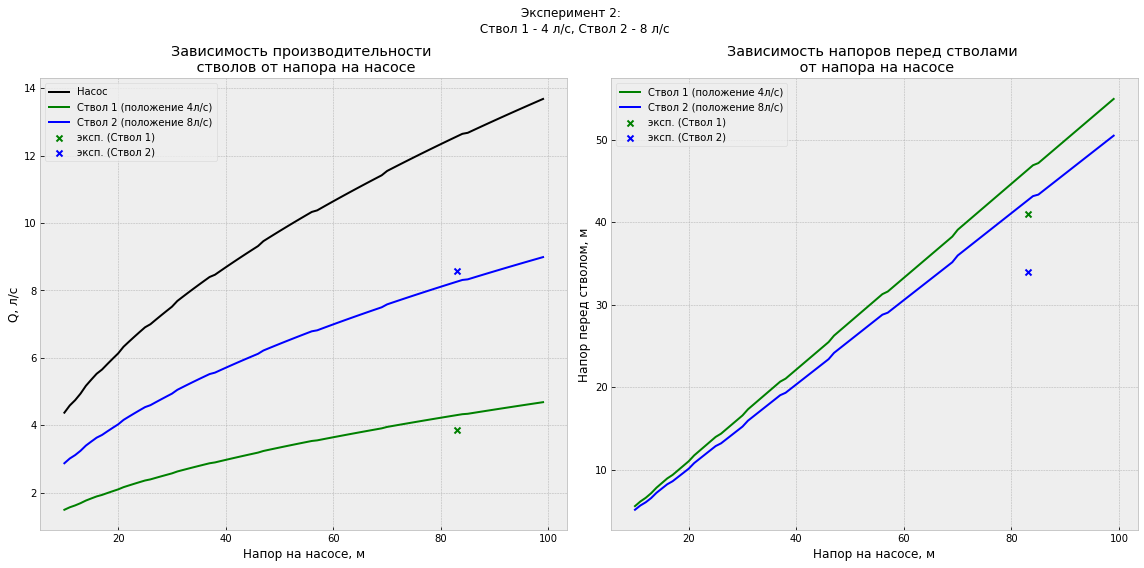

In [14]:
plt.style.use('bmh')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

ax1.plot(h_pump, q_pump, c='k', label='Насос')
ax1.plot(h_pump, q_n1, c='g', label='Ствол 1 (положение 4л/с)')
ax1.plot(h_pump, q_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax1.scatter([83], [3.86], marker='x', c='g', label='эксп. (Ствол 1)')
ax1.scatter([83], [8.58], marker='x', c='b', label='эксп. (Ствол 2)')
ax1.set_xlabel('Напор на насосе, м')
ax1.set_ylabel('Q, л/с')
ax1.legend()
ax1.set_title('Зависимость производительности \n стволов от напора на насосе')

ax2.plot(h_pump, h_n1, c='g', label='Ствол 1 (положение 4л/с)')
ax2.plot(h_pump, h_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax2.scatter([83], [41], marker='x', c='g', label='эксп. (Ствол 1)')
ax2.scatter([83], [34], marker='x', c='b', label='эксп. (Ствол 2)')
ax2.set_xlabel('Напор на насосе, м')
ax2.set_ylabel('Напор перед стволом, м')
ax2.set_title('Зависимость напоров перед стволами \n от напора на насосе')
ax2.legend()

fig.suptitle('Эксперимент 2: \n Ствол 1 - 4 л/с, Ствол 2 - 8 л/с')
fig.tight_layout()
plt.show()

### Эксперимент 3

- Ствол 1 - положение 8 л/с
- Ствол 2 - положение 8 л/с

In [ ]:
# Предварительная настройка модели

# Сброс состояния
model.drop_q()

# Расчет НРС с новыми параметрами:
pump.set_H_add(10)
nozzle_11.p = p_8
model, r = model.calc(accuracy=0.05)

In [ ]:
# Насос
h_pump = []
q_pump = []
# Ствол 1
h_n1   = []
q_n1   = []
# Ствол 2
h_n2   = []
q_n2   = []

# Моделирование:
for h in range (10, 100):
    
    # Шаг моделирования
    model.drop_q()
    # Напор на насосе
    pump.set_H_add(h)
    model, r = model.calc(accuracy=0.05)

    # Запоминаем результат
    h_pump.append(h)
    q_pump.append(pump.q)
    h_n1.append(nozzle_11.H_in)
    q_n1.append(nozzle_11.q)
    h_n2.append(nozzle_12.H_in)
    q_n2.append(nozzle_12.q)

In [ ]:
plt.style.use('bmh')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

ax1.plot(h_pump, q_pump, c='k', label='Насос')
ax1.plot(h_pump, q_n1, c='g', label='Ствол 1 (положение 8л/с)')
ax1.plot(h_pump, q_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax1.scatter([82, 99], [6.58, 7.3], marker='x', c='g', label='эксп. (Ствол 1)')
ax1.scatter([82, 99], [7.33, 8.16], marker='x', c='b', label='эксп. (Ствол 2)')
ax1.set_xlabel('Напор на насосе, м')
ax1.set_ylabel('Q, л/с')
ax1.legend()
ax1.set_title('Зависимость производительности \n стволов от напора на насосе')

ax2.plot(h_pump, h_n1, c='g', label='Ствол 1 (положение 8л/с)')
ax2.plot(h_pump, h_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax2.scatter([82, 99], [27, 33], marker='x', c='g', label='эксп. (Ствол 1)')
ax2.scatter([82, 99], [25, 31], marker='x', c='b', label='эксп. (Ствол 2)')
ax2.set_xlabel('Напор на насосе, м')
ax2.set_ylabel('Напор перед стволом, м')
ax2.set_title('Зависимость напоров перед стволами \n от напора на насосе')
ax2.legend()

fig.suptitle('Эксперимент 3: \n Ствол 1 - 8 л/с, Ствол 2 - 8 л/с')
fig.tight_layout()
plt.show()

### Эксперимент 4

- Ствол 1 - положение 0 л/с
- Ствол 2 - положение 8 л/с

In [16]:
# Предварительная настройка модели

# Сброс состояния
model.drop_q()

# Расчет НРС с новыми параметрами:
pump.set_H_add(10)
nozzle_11.p = 0
model, r = model.calc(accuracy=0.05)

In [17]:
# Насос
h_pump = []
q_pump = []
# Ствол 1
h_n1   = []
q_n1   = []
# Ствол 2
h_n2   = []
q_n2   = []

# Моделирование:
for h in range (10, 110):
    
    # Шаг моделирования
    model.drop_q()
    # Напор на насосе
    pump.set_H_add(h)
    model, r = model.calc(accuracy=0.05)

    # Запоминаем результат
    h_pump.append(h)
    q_pump.append(pump.q)
    h_n1.append(nozzle_11.H_in)
    q_n1.append(nozzle_11.q)
    h_n2.append(nozzle_12.H_in)
    q_n2.append(nozzle_12.q)

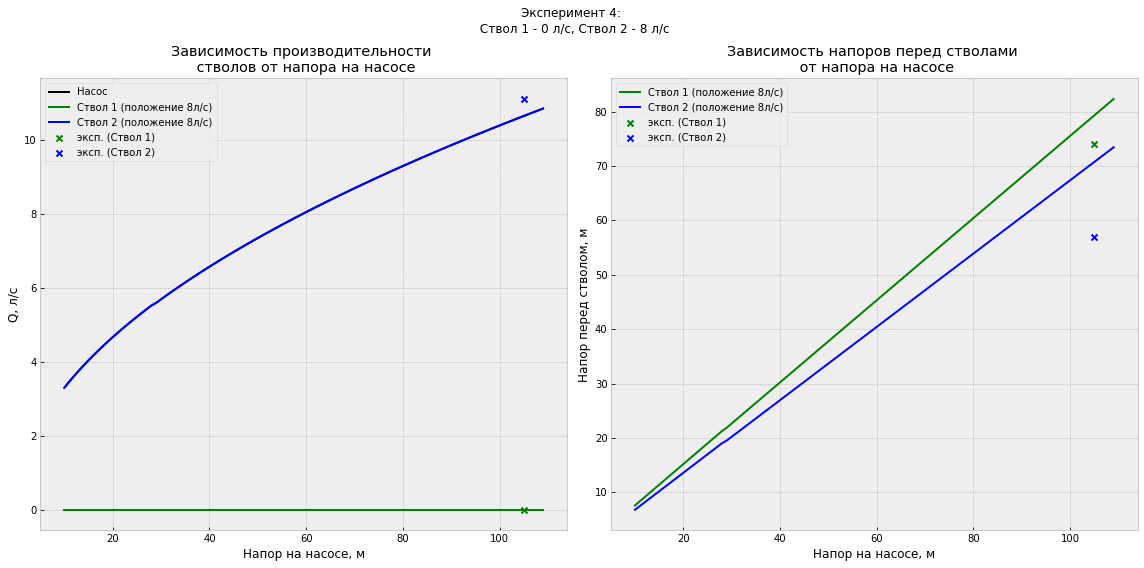

In [18]:
plt.style.use('bmh')

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8))

ax1.plot(h_pump, q_pump, c='k', label='Насос')
ax1.plot(h_pump, q_n1, c='g', label='Ствол 1 (положение 8л/с)')
ax1.plot(h_pump, q_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax1.scatter([105], [0], marker='x', c='g', label='эксп. (Ствол 1)')
ax1.scatter([105], [11.1], marker='x', c='b', label='эксп. (Ствол 2)')
ax1.set_xlabel('Напор на насосе, м')
ax1.set_ylabel('Q, л/с')
ax1.legend()
ax1.set_title('Зависимость производительности \n стволов от напора на насосе')

ax2.plot(h_pump, h_n1, c='g', label='Ствол 1 (положение 8л/с)')
ax2.plot(h_pump, h_n2, c='b', label='Ствол 2 (положение 8л/с)')
ax2.scatter([105], [74], marker='x', c='g', label='эксп. (Ствол 1)')
ax2.scatter([105], [57], marker='x', c='b', label='эксп. (Ствол 2)')
ax2.set_xlabel('Напор на насосе, м')
ax2.set_ylabel('Напор перед стволом, м')
ax2.set_title('Зависимость напоров перед стволами \n от напора на насосе')
ax2.legend()

fig.suptitle('Эксперимент 4: \n Ствол 1 - 0 л/с, Ствол 2 - 8 л/с')
fig.tight_layout()
plt.show()